# Predicción de comportamiento de compra en eCommerce con Big Data y PySpark

**Equipo 54**  
Salma Alejandra Macías Rosas — A01620186  
Marcelo Ismael López Verdugo — A00959089  
Dario Maximiliano Mendoza Orozco — A01361220  
Diana Jimena López Nájera — A01024913  

**Materia:** Análisis de grandes volúmenes de datos  
**Profesor:** Dr. Iván Olmos Pineda  
**Proyecto:** Comportamiento de usuarios en comercio electrónico  

## Contexto

El proyecto utiliza el dataset **eCommerce behavior data from multi category store**, específicamente el archivo de octubre de 2019. Cada registro representa un evento realizado por un usuario dentro de una tienda en línea multi-categoría, como visualizar un producto, agregarlo al carrito o comprarlo. El objetivo es analizar patrones de navegación y construir un modelo que permita predecir si un evento corresponde a una compra.

La población analizada contiene eventos de comportamiento a gran escala, por lo que el procesamiento se realiza con **PySpark**. Dado el fuerte desbalance natural del embudo de conversión —donde las visualizaciones son mucho más frecuentes que las compras— el flujo incorpora muestreo estratificado proporcional, validación cruzada k-fold y evaluación mediante F1-score ponderado.


!
!apt-get update -qq > /dev/null
!apt-get install openjdk-17-jdk-headless -qq > /dev/null
!wget -q https://dlcdn.apache.org/spark/spark-3.5.8/spark-3.5.8-bin-hadoop3.tgz
!tar -xzf spark-3.5.8-bin-hadoop3.tgz
!pip install -q findspark

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.8-bin-hadoop3"

!ls

import findspark
findspark.init()
from pyspark import SparkContext, SparkConf, SQLContext
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()
spark.conf.set("spark.sql.repl.eagerEval.enabled", True) # Property used to format output tables better
spark

from google.colab import drive
drive.mount('/content/drive')



import os
DIR = "/content/drive/MyDrive/Masters TEC/Materias/Big data /Big Data Notebooks"
os.chdir(DIR)

import os

# The DIR variable from a previous cell holds the path to the Google Drive folder.
# Using this to construct the absolute path to the CSV file.
DIR = '/content/drive/MyDrive/Masters TEC/Materias/Big data /Big Data Notebooks'
path = os.path.join(DIR, "2019-Oct.csv")

# Load data from file
df = spark.read.csv(path, header=True, inferSchema=True)


# Show first 3 rows
df.show(3)




# ==============================================================================
# IMPORTACIONES Y PREPARACIÓN DE DATOS (Basado en el código base del equipo)
# ==============================================================================
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, sum, avg, when, isnan, lit, desc, hour, dayofweek, rand
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# 1. Iniciar SparkSession
spark = SparkSession.builder \
    .appName("Actividad5_Visualizacion_Eq74") \
    .config("spark.driver.memory", "6g") \
    .getOrCreate()

file_path="../datasets/2019-Oct.csv" # Ruta local
df = spark.read.option("header", True).option("inferSchema", True).csv(file_path)


df_raw = df

## 1. Preparación del entorno

Se inicializa una sesión de Spark configurada para procesamiento distribuido. Las librerías de PySpark se utilizan para carga, limpieza, transformación, muestreo y modelado. Pandas, Matplotlib y Seaborn se usan únicamente al final para visualizaciones sobre subconjuntos agregados o muestras controladas, evitando mover el dataset completo al driver.


import os
import sys

py = sys.executable
os.environ["PYSPARK_PYTHON"] = py
os.environ["PYSPARK_DRIVER_PYTHON"] = py

print("Python used by Spark:", py)

In [1]:
# ============================================================
# 1. IMPORTACIONES Y CONFIGURACIÓN INICIAL
# ============================================================

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType, StringType, TimestampType

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.evaluation import BinaryClassificationEvaluator


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

SEED = 42
K_FOLDS = 3
SAMPLE_FRACTION = 0.010  # Ajustable según recursos del ambiente
MAX_BRANDS = 50         # Agrupación de marcas para controlar cardinalidad

spark = (
    SparkSession.builder
    .appName("Equipo54_Ecommerce_BigData_ML")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.driver.memory", "96g")
    .getOrCreate()
)


file_path="../datasets/2019-Oct.csv" # Ruta local
df = spark.read.option("header", True).option("inferSchema", True).csv(file_path)
df_raw=df

spark.sparkContext.setLogLevel("WARN")
print("SparkSession iniciada correctamente")


SparkSession iniciada correctamente


## 2. Carga de datos con PySpark

El dataset se encuentra en formato CSV y contiene eventos del mes de octubre de 2019. La ruta puede modificarse de acuerdo con el ambiente de ejecución: Google Colab, Databricks, ambiente local o clúster Spark.


## 3. Exploración inicial del dataset (EDA)

La exploración inicial valida volumen, estructura, tipos de datos, distribución de eventos, valores faltantes y estadísticas básicas de precio. Esta etapa es clave porque el dataset presenta un fuerte desbalance entre eventos de visualización, carrito y compra.


In [2]:
# ============================================================
# 3. EXPLORACIÓN INICIAL DEL DATASET
# ============================================================

# Vista inicial
print("Primeros registros:")
df_raw.show(5, truncate=False)

# Conteo de registros y columnas
n_rows = df_raw.count()
n_cols = len(df_raw.columns)
print(f"Dimensión del dataset: {n_rows:,} registros x {n_cols} columnas")

# Distribución de event_type
print("Distribución de event_type:")
(
    df_raw.groupBy("event_type")
    .count()
    .withColumn("porcentaje", F.round(F.col("count") / F.lit(n_rows) * 100, 4))
    .orderBy(F.desc("count"))
    .show(truncate=False)
)

# Valores faltantes por columna
missing_exprs = [
    F.sum(
        F.when(F.col(c).isNull() | (F.col(c).cast("string") == ""), 1).otherwise(0)
    ).alias(c)
    for c in df_raw.columns
]
print("Valores faltantes por columna:")
df_raw.select(missing_exprs).show(truncate=False)

# Estadística descriptiva de precio
print("Estadísticos de price:")
df_raw.select("price").describe().show()


Primeros registros:
+-------------------+----------+----------+-------------------+-----------------------------------+--------+-------+---------+------------------------------------+
|event_time         |event_type|product_id|category_id        |category_code                      |brand   |price  |user_id  |user_session                        |
+-------------------+----------+----------+-------------------+-----------------------------------+--------+-------+---------+------------------------------------+
|2019-09-30 17:00:00|view      |44600062  |2103807459595387724|NULL                               |shiseido|35.79  |541312140|72d76fde-8bb3-4e00-8c23-a032dfed738c|
|2019-09-30 17:00:00|view      |3900821   |2053013552326770905|appliances.environment.water_heater|aqua    |33.2   |554748717|9333dfbd-b87a-4708-9857-6336556b0fcc|
|2019-09-30 17:00:01|view      |17200506  |2053013559792632471|furniture.living_room.sofa         |NULL    |543.1  |519107250|566511c2-e2e3-422b-b695-cf8e6e792c

## 4. Limpieza de datos

La limpieza se realiza sin eliminar de forma masiva los registros con valores nulos en `category_code` y `brand`, porque esos faltantes representan una proporción relevante de la población. En su lugar, se asigna la etiqueta `unknown`, manteniendo la representatividad del dataset.

También se validan tipos de datos para asegurar que `event_time` sea timestamp y `price` sea numérico. Los registros con precio nulo o negativo se eliminan porque no son válidos para el análisis de rangos de precio ni para el modelo.


In [3]:
# ============================================================
# 4. LIMPIEZA DE DATOS Y VALIDACIÓN DE TIPOS
# ============================================================

required_cols = [
    "event_time", "event_type", "product_id", "category_id",
    "category_code", "brand", "price", "user_id", "user_session"
]

missing_required = [c for c in required_cols if c not in df_raw.columns]
if missing_required:
    raise ValueError(f"Faltan columnas requeridas: {missing_required}")

# Conversión explícita de tipos relevantes
df_clean = (
    df_raw
    .withColumn("event_time", F.to_timestamp("event_time"))
    .withColumn("price", F.col("price").cast(DoubleType()))
    .withColumn("event_type", F.col("event_type").cast(StringType()))
    .withColumn("category_code", F.col("category_code").cast(StringType()))
    .withColumn("brand", F.col("brand").cast(StringType()))
)

# Manejo de nulos en variables categóricas relevantes
df_clean = (
    df_clean
    .withColumn(
        "category_code_clean",
        F.when(F.col("category_code").isNull() | (F.trim(F.col("category_code")) == ""), F.lit("unknown"))
         .otherwise(F.col("category_code"))
    )
    .withColumn(
        "brand_clean",
        F.when(F.col("brand").isNull() | (F.trim(F.col("brand")) == ""), F.lit("unknown"))
         .otherwise(F.lower(F.col("brand")))
    )
)

# Reglas mínimas de calidad: timestamp válido, event_type válido y price no negativo
df_clean = (
    df_clean
    .filter(F.col("event_time").isNotNull())
    .filter(F.col("event_type").isin("view", "cart", "purchase"))
    .filter(F.col("price").isNotNull() & (F.col("price") >= 0))
)

print(f"Registros después de limpieza: {df_clean.count():,}")
df_clean.select("event_time", "event_type", "category_code_clean", "brand_clean", "price").show(5, truncate=False)


Registros después de limpieza: 42,448,764
+-------------------+----------+-----------------------------------+-----------+-------+
|event_time         |event_type|category_code_clean                |brand_clean|price  |
+-------------------+----------+-----------------------------------+-----------+-------+
|2019-09-30 17:00:00|view      |unknown                            |shiseido   |35.79  |
|2019-09-30 17:00:00|view      |appliances.environment.water_heater|aqua       |33.2   |
|2019-09-30 17:00:01|view      |furniture.living_room.sofa         |unknown    |543.1  |
|2019-09-30 17:00:01|view      |computers.notebook                 |lenovo     |251.74 |
|2019-09-30 17:00:04|view      |electronics.smartphone             |apple      |1081.98|
+-------------------+----------+-----------------------------------+-----------+-------+
only showing top 5 rows


## 5. Feature engineering

Se construyen variables derivadas coherentes con el particionamiento del proyecto:

- `weekhour`: combinación de día de la semana y hora para capturar patrón temporal semanal.
- `category_group`: categoría principal antes del primer punto en `category_code`.
- `price_range`: rango de precio (`low`, `medium`, `high`) usando los percentiles documentados en la caracterización: P25 = 64.78 y P75 = 357.77.
- `time_period`: periodo del día (`night`, `morning`, `afternoon`, `evening`) a partir de la hora del evento.
- `brand_grouped`: agrupación de marcas frecuentes y etiqueta `other` para controlar alta cardinalidad.


In [4]:
# ============================================================
# 5. FEATURE ENGINEERING
# ============================================================

# Percentiles documentados en la caracterización del dataset
P25_PRICE = 64.78
P75_PRICE = 357.77

# Variables temporales y de particionamiento
df_fe = (
    df_clean
    .withColumn("hour", F.hour("event_time"))
    .withColumn("day_of_week", F.dayofweek("event_time"))
    .withColumn("weekhour", F.col("day_of_week") + F.col("hour") / F.lit(24.0))
    .withColumn("category_group", F.split(F.col("category_code_clean"), "\\.").getItem(0))
    .withColumn(
        "price_range",
        F.when(F.col("price") <= F.lit(P25_PRICE), F.lit("low"))
         .when(F.col("price") <= F.lit(P75_PRICE), F.lit("medium"))
         .otherwise(F.lit("high"))
    )
    .withColumn(
        "time_period",
        F.when((F.col("hour") >= 0) & (F.col("hour") < 6), F.lit("night"))
         .when((F.col("hour") >= 6) & (F.col("hour") < 12), F.lit("morning"))
         .when((F.col("hour") >= 12) & (F.col("hour") < 18), F.lit("afternoon"))
         .otherwise(F.lit("evening"))
    )
)

# Agrupación de marcas para controlar cardinalidad en el pipeline ML
top_brands = [
    r["brand_clean"]
    for r in (
        df_fe.groupBy("brand_clean")
        .count()
        .orderBy(F.desc("count"))
        .limit(MAX_BRANDS)
        .collect()
    )
]

df_fe = df_fe.withColumn(
    "brand_grouped",
    F.when(F.col("brand_clean").isin(top_brands), F.col("brand_clean")).otherwise(F.lit("other"))
)

# Validación rápida de variables derivadas
df_fe.select(
    "event_type", "category_code_clean", "category_group", "brand_grouped",
    "price", "price_range", "hour", "time_period", "weekhour"
).show(10, truncate=False)


+----------+-----------------------------------+--------------+-------------+-------+-----------+----+-----------+------------------+
|event_type|category_code_clean                |category_group|brand_grouped|price  |price_range|hour|time_period|weekhour          |
+----------+-----------------------------------+--------------+-------------+-------+-----------+----+-----------+------------------+
|view      |unknown                            |unknown       |other        |35.79  |low        |17  |afternoon  |2.7083333333333335|
|view      |appliances.environment.water_heater|appliances    |other        |33.2   |low        |17  |afternoon  |2.7083333333333335|
|view      |furniture.living_room.sofa         |furniture     |unknown      |543.1  |high       |17  |afternoon  |2.7083333333333335|
|view      |computers.notebook                 |computers     |lenovo       |251.74 |medium     |17  |afternoon  |2.7083333333333335|
|view      |electronics.smartphone             |electronics   

## 6. Construcción de muestra representativa

La muestra se construye mediante **muestreo estratificado proporcional**. Cada estrato se define por la combinación:

`event_type + category_group + price_range + time_period`

Esta regla conserva la estructura poblacional observada en el proyecto: acción del usuario, categoría general del producto, nivel de precio y periodo del día. Al aplicar la misma fracción de muestreo por estrato, se mantiene la proporción original de cada combinación dentro de la muestra.


In [5]:
# ============================================================
# 6. MUESTREO ESTRATIFICADO PROPORCIONAL
# ============================================================
SAMPLE_FRACTION=0.01
strata_cols = ["event_type", "category_group", "price_range", "time_period"]

# Crear identificador de estrato
df_strata = df_fe.withColumn("stratum", F.concat_ws("__", *[F.col(c) for c in strata_cols]))

# Calcular distribución poblacional por estrato para auditoría
strata_distribution = (
    df_strata.groupBy(strata_cols + ["stratum"])
    .count()
    .withColumn("population_share", F.col("count") / F.lit(df_strata.count()))
)

print("Principales estratos en la población:")
strata_distribution.orderBy(F.desc("count")).show(15, truncate=False)

# sampleBy requiere un diccionario {estrato: fracción}
strata_values = [r["stratum"] for r in df_strata.select("stratum").distinct().collect()]
fractions = {s: SAMPLE_FRACTION for s in strata_values}

M = (
    df_strata
    .sampleBy("stratum", fractions=fractions, seed=SEED)
    .cache()
)

m_count = M.count()
print(f"Tamaño de la muestra M: {m_count:,} registros")

print("Distribución de event_type en la muestra:")
(
    M.groupBy("event_type")
    .count()
    .withColumn("sample_share", F.round(F.col("count") / F.lit(m_count) * 100, 4))
    .orderBy(F.desc("count"))
    .show(truncate=False)
)


Principales estratos en la población:
+----------+--------------+-----------+-----------+----------------------------------+-------+--------------------+
|event_type|category_group|price_range|time_period|stratum                           |count  |population_share    |
+----------+--------------+-----------+-----------+----------------------------------+-------+--------------------+
|view      |electronics   |medium     |morning    |view__electronics__medium__morning|3026270|0.07129229958262154 |
|view      |electronics   |medium     |night      |view__electronics__medium__night  |2578533|0.06074459553168615 |
|view      |unknown       |medium     |morning    |view__unknown__medium__morning    |2226350|0.052447934644221914|
|view      |electronics   |high       |morning    |view__electronics__high__morning  |2212422|0.052119821439323887|
|view      |unknown       |low        |morning    |view__unknown__low__morning       |2099047|0.04944895450901703 |
|view      |electronics   |high   

## 7. Definición de variable objetivo

Se define la variable binaria `compro`:

- `compro = 1` si `event_type = purchase`
- `compro = 0` si `event_type` es `view` o `cart`

Importante: después de crear la etiqueta, `event_type` no se utiliza como variable predictora para evitar fuga de información, ya que define directamente la clase objetivo.


In [6]:
# ============================================================
# 7. VARIABLE OBJETIVO
# ============================================================

M = M.withColumn("compro", F.when(F.col("event_type") == "purchase", F.lit(1.0)).otherwise(F.lit(0.0)))

print("Distribución de la variable objetivo compro:")
(
    M.groupBy("compro")
    .count()
    .withColumn("porcentaje", F.round(F.col("count") / F.lit(M.count()) * 100, 4))
    .orderBy("compro")
    .show()
)


Distribución de la variable objetivo compro:
+------+------+----------+
|compro| count|porcentaje|
+------+------+----------+
|   0.0|417937|   98.2637|
|   1.0|  7385|    1.7363|
+------+------+----------+



## 8. División de datos mediante k-fold

Se utiliza validación cruzada manual con **k = 3**. La elección de k responde a un balance explícito entre tres factores:

1. **Compromiso sesgo-varianza.** Un k pequeño (p. ej. 2) deja conjuntos de validación grandes pero entrena con menos datos por iteración; un k grande (p. ej. 10) reduce el sesgo pero aumenta la varianza de la estimación y el costo. Con k = 3 cada iteración entrena con ~2/3 de la muestra y valida con ~1/3.

2. **Tamaño del conjunto de validación.** Como la muestra M tiene ~4.2 millones de registros, cada fold de validación contiene ~1.4 millones de eventos. Ese tamaño ya es estadísticamente robusto, por lo que aumentar k aporta poca reducción adicional de varianza y sí mucho costo.

3. **Costo computacional en Big Data.** Cada fold implica ajustar el pipeline completo (StringIndexer, OneHotEncoder, VectorAssembler, árbol) y operaciones de *shuffle* sobre millones de registros. El tiempo y la memoria crecen de forma aproximadamente lineal con k.

La estabilidad observada entre folds (desviación estándar del F1 del orden de 1×10⁻⁴) confirma empíricamente que k = 3 es suficiente para una estimación robusta. La representatividad de los folds —por tamaño, por clase y por estrato— se verifica explícitamente en la sección 8.1.


In [7]:
# ============================================================
# 8. CREACIÓN DE FOLDS
# ============================================================

M_folds = M.withColumn("fold", (F.rand(seed=SEED) * F.lit(K_FOLDS)).cast(IntegerType()))

print("Distribución de registros por fold:")
(
    M_folds.groupBy("fold")
    .count()
    .withColumn("porcentaje", F.round(F.col("count") / F.lit(M_folds.count()) * 100, 4))
    .orderBy("fold")
    .show()
)

print("Distribución de compro por fold:")
(
    M_folds.groupBy("fold", "compro")
    .count()
    .orderBy("fold", "compro")
    .show()
)


Distribución de registros por fold:
+----+------+----------+
|fold| count|porcentaje|
+----+------+----------+
|   0|142011|   33.3891|
|   1|141633|   33.3002|
|   2|141678|   33.3108|
+----+------+----------+

Distribución de compro por fold:
+----+------+------+
|fold|compro| count|
+----+------+------+
|   0|   0.0|139550|
|   0|   1.0|  2461|
|   1|   0.0|139173|
|   1|   1.0|  2460|
|   2|   0.0|139214|
|   2|   1.0|  2464|
+----+------+------+



## 8.1 Representatividad de los folds

Además del tamaño, se verifica que cada fold conserve la proporción de la clase objetivo `compro` y la composición de los estratos usados en el muestreo. Una desviación cercana a cero indica que los folds son representativos de la población y comparables entre sí.


In [8]:
# ============================================================
# 8.1 REPRESENTATIVIDAD DE LOS FOLDS (POR CLASE Y POR ESTRATO)
# ============================================================
# El profesor pidió verificar la representatividad no solo por tamaño, sino
# también por clase y por las particiones (estratos) definidas previamente.

m_total = M_folds.count()

# (a) Proporción de la clase objetivo por fold (debe ser ~1.74% en todos)
print("Proporción de compro=1 por fold:")
(
    M_folds.groupBy("fold")
    .agg(F.count("*").alias("n"),
         F.round(F.avg("compro") * 100, 4).alias("pct_compra"))
    .orderBy("fold")
    .show()
)

# (b) Representatividad de los estratos: participación de cada estrato en la
#     población (M) vs. en cada fold, resumida como desviación absoluta media.
pop_share = (
    M_folds.groupBy("stratum")
    .agg((F.count("*") / F.lit(m_total)).alias("pop_share"))
)
fold_tot = M_folds.groupBy("fold").agg(F.count("*").alias("fold_n"))
fold_share = (
    M_folds.groupBy("fold", "stratum").count()
    .join(fold_tot, "fold")
    .withColumn("fold_share", F.col("count") / F.col("fold_n"))
)
rep = (
    fold_share.join(pop_share, "stratum")
    .withColumn("abs_diff", F.abs(F.col("fold_share") - F.col("pop_share")))
)
print("Desviación absoluta media de la composición de estratos por fold (%):")
(
    rep.groupBy("fold")
    .agg(F.round(F.avg("abs_diff") * 100, 6).alias("desv_media_pct"))
    .orderBy("fold")
    .show()
)


Proporción de compro=1 por fold:
+----+------+----------+
|fold|     n|pct_compra|
+----+------+----------+
|   0|142011|     1.733|
|   1|141633|    1.7369|
|   2|141678|    1.7392|
+----+------+----------+

Desviación absoluta media de la composición de estratos por fold (%):
+----+--------------+
|fold|desv_media_pct|
+----+--------------+
|   0|      0.005673|
|   1|       0.00551|
|   2|      0.004675|
+----+--------------+



## 8.2 Pesos de clase para tratar el desbalance

El F1-score ponderado puede ocultar el mal desempeño en la clase minoritaria: un modelo que prediga siempre "no compra" obtiene métricas globales altas pero no detecta ninguna conversión. Para evitar que el árbol colapse a la clase mayoritaria, se agregan **pesos de clase balanceados** (inversamente proporcionales a la frecuencia de cada clase), que el `DecisionTreeClassifier` usa mediante `weightCol`.


In [9]:
# ============================================================
# 8.2 PESOS DE CLASE BALANCEADOS
# ============================================================
n_total = M_folds.count()
n_pos = M_folds.filter(F.col("compro") == 1.0).count()
n_neg = n_total - n_pos

w_pos = n_total / (2.0 * n_pos)
w_neg = n_total / (2.0 * n_neg)
print(f"Peso clase 1 (compra):    {w_pos:.4f}")
print(f"Peso clase 0 (no compra): {w_neg:.4f}")

M_folds = M_folds.withColumn(
    "classWeight",
    F.when(F.col("compro") == 1.0, F.lit(w_pos)).otherwise(F.lit(w_neg))
)


Peso clase 1 (compra):    28.7963
Peso clase 0 (no compra): 0.5088


## 9. Pipeline de Machine Learning

El pipeline utiliza:

1. `StringIndexer` para convertir categorías en índices numéricos.
2. `OneHotEncoder` para representar categorías sin imponer ordinalidad.
3. `VectorAssembler` para integrar variables categóricas codificadas y variables numéricas.
4. `DecisionTreeClassifier` como modelo interpretable para clasificación binaria.

El Árbol de Decisión es apropiado como modelo base porque permite capturar relaciones no lineales, interacciones simples entre variables y reglas interpretables para negocio.


In [140]:
# ============================================================
# 9. DEFINICIÓN DEL PIPELINE DE MACHINE LEARNING
# ============================================================
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.classification import DecisionTreeClassifier, LogisticRegression, NaiveBayes,RandomForestClassifier, GBTClassifier

evaluator_auc = BinaryClassificationEvaluator(
    labelCol="compro",
    rawPredictionCol="probability",
    metricName="areaUnderROC"
)

categorical_features = ["category_group", "price_range", "time_period", "brand_grouped"]
numeric_features = ["price", "weekhour"]

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_features
]
encoders = [
    OneHotEncoder(
        inputCols=[f"{c}_idx" for c in categorical_features],
        outputCols=[f"{c}_vec" for c in categorical_features],
        handleInvalid="keep"
    )
]
assembler = VectorAssembler(
    inputCols=[f"{c}_vec" for c in categorical_features] + numeric_features,
    outputCol="features",
    handleInvalid="keep"
)

# Cambia este valor para probar otro modelo:
# opciones: "logreg", "nb", "dt", "rf", "GBT"
model_type = "GBT"

if model_type == "logreg":
    model = LogisticRegression(
        labelCol="compro",
        featuresCol="features",
        weightCol="classWeight",
        maxIter=50,
        regParam=0.01,
        elasticNetParam=0.0
    )
elif model_type == "nb":
    model = NaiveBayes(
        labelCol="compro",
        featuresCol="features",
        weightCol="classWeight",
        smoothing=0.1,
        modelType="complement"
    )
elif model_type == "GBT":
    model = GBTClassifier(
        labelCol="compro",
        featuresCol="features",
        weightCol="classWeight",
        maxIter=50,
        maxDepth=5,
    )
elif model_type == "rf":
    model = RandomForestClassifier(
        labelCol="compro",
        featuresCol="features",
        numTrees=100,
        maxDepth=2,
        seed=SEED
    )
else:
    model = DecisionTreeClassifier(
        labelCol="compro",
        featuresCol="features",
        weightCol="classWeight",
        maxDepth=2,
        minInstancesPerNode=50,
        seed=SEED
    )

pipeline = Pipeline(stages=indexers + encoders + [assembler, model])

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="compro", predictionCol="prediction", metricName="f1"
)
evaluator_accuracy = MulticlassClassificationEvaluator(
    labelCol="compro", predictionCol="prediction", metricName="accuracy"
)
evaluator_auc = BinaryClassificationEvaluator(
    labelCol="compro", rawPredictionCol="probability", metricName="areaUnderROC"
)

## 10. Entrenamiento, evaluación y validación cruzada

En cada fold se entrena el pipeline con dos tercios de la muestra y se valida con el tercio restante. Se calcula F1-score ponderado tanto en entrenamiento como en validación para observar desempeño y detectar posible sobreajuste.


In [141]:
# ============================================================
# 10. ENTRENAMIENTO, VALIDACIÓN CRUZADA Y MÉTRICAS POR CLASE
# ============================================================

def per_label(pred, metric, label):
    return MulticlassClassificationEvaluator(
        labelCol="compro", predictionCol="prediction",
        metricName=metric, metricLabel=label
    ).evaluate(pred)

resultados_cv = []
models = []

for i in range(K_FOLDS):
    print(f"\n================ Fold {i + 1}/{K_FOLDS} ================")
    start_time = time.time()

    train_df = M_folds.filter(F.col("fold") != i)
    val_df = M_folds.filter(F.col("fold") == i)

    train_count = train_df.count()
    val_count = val_df.count()
    print(f"Train: {train_count:,} | Validation: {val_count:,}")

    model = pipeline.fit(train_df)
    models.append(model)

    pred_train = model.transform(train_df)
    pred_val = model.transform(val_df)

    # Métricas globales
    f1_train = evaluator_f1.evaluate(pred_train)
    f1_val = evaluator_f1.evaluate(pred_val)
    acc_val = evaluator_accuracy.evaluate(pred_val)

    # Métricas de la clase minoritaria (compra = 1)
    prec_1 = per_label(pred_val, "precisionByLabel", 1.0)
    rec_1 = per_label(pred_val, "recallByLabel", 1.0)
    f1_1 = per_label(pred_val, "fMeasureByLabel", 1.0)

    # AUC-ROC
    auc = evaluator_auc.evaluate(pred_val)

    elapsed = time.time() - start_time

    resultados_cv.append({
        "Fold": i + 1,
        "Train_Count": train_count,
        "Validation_Count": val_count,
        "F1_Train": f1_train,
        "F1_Validation": f1_val,
        "Accuracy_Validation": acc_val,
        "Precision_compra": prec_1,
        "Recall_compra": rec_1,
        "F1_compra": f1_1,
        "AUC_ROC": auc,
        "Tiempo_segundos": elapsed
    })

    print(f"F1 ponderado (val): {f1_val:.4f} | Accuracy (val): {acc_val:.4f}")
    print(f"Clase compra -> Precision: {prec_1:.4f} | Recall: {rec_1:.4f} | F1: {f1_1:.4f}")
    print(f"AUC-ROC (val): {auc:.4f} | Tiempo: {elapsed:.2f}s")

resultados_pdf = pd.DataFrame(resultados_cv)
resultados_pdf



================ Fold 1/3 ================
Train: 283,311 | Validation: 142,011
F1 ponderado (val): 0.7672 | Accuracy (val): 0.6429
Clase compra -> Precision: 0.0297 | Recall: 0.6189 | F1: 0.0567
AUC-ROC (val): 0.6778 | Tiempo: 167.64s

================ Fold 2/3 ================
Train: 283,689 | Validation: 141,633
F1 ponderado (val): 0.7756 | Accuracy (val): 0.6543
Clase compra -> Precision: 0.0298 | Recall: 0.5984 | F1: 0.0567
AUC-ROC (val): 0.6728 | Tiempo: 351.05s

================ Fold 3/3 ================
Train: 283,644 | Validation: 141,678
F1 ponderado (val): 0.7708 | Accuracy (val): 0.6477
Clase compra -> Precision: 0.0295 | Recall: 0.6043 | F1: 0.0563
AUC-ROC (val): 0.6725 | Tiempo: 143.37s


,Fold,Train_Count,Validation_Count,F1_Train,F1_Validation,Accuracy_Validation,Precision_compra,Recall_compra,F1_compra,AUC_ROC,Tiempo_segundos
0,1,283311,142011,0.768220,0.767245,0.642915,0.029691,0.618854,0.056663,0.677840,167.644749
1,2,283689,141633,0.777171,0.775650,0.654283,0.029768,0.598374,0.056715,0.672781,351.047438
2,3,283644,141678,0.771139,0.770758,0.647673,0.029525,0.604302,0.056300,0.672490,143.366580


## 11. Justificación del F1-score ponderado

El dataset está desbalanceado porque la mayor parte de los eventos son visualizaciones y solo una proporción pequeña corresponde a compras. En este contexto, la exactitud puede ser engañosa: un modelo que prediga casi todo como “no compra” podría obtener alta accuracy, pero sería poco útil para identificar conversiones.

El **F1-score ponderado** combina precisión y recall por clase, ponderando cada clase de acuerdo con su soporte. Por ello, ofrece una lectura más adecuada del desempeño global en un problema de conversión desbalanceado.


In [142]:
# ============================================================
# 11. RESUMEN DE MÉTRICAS (GLOBALES Y POR CLASE)
# ============================================================
print("Resultados por fold:")
print(resultados_pdf.to_string(index=False))

print("\nPromedios y desviación estándar (validación):")
for col in ["F1_Validation", "Accuracy_Validation", "Precision_compra",
            "Recall_compra", "F1_compra", "AUC_ROC"]:
    print(f"{col:>22}: media={resultados_pdf[col].mean():.4f}  std={resultados_pdf[col].std():.4f}")


Resultados por fold:
 Fold  Train_Count  Validation_Count  F1_Train  F1_Validation  Accuracy_Validation  Precision_compra  Recall_compra  F1_compra  AUC_ROC  Tiempo_segundos
    1       283311            142011  0.768220       0.767245             0.642915          0.029691       0.618854   0.056663 0.677840       167.644749
    2       283689            141633  0.777171       0.775650             0.654283          0.029768       0.598374   0.056715 0.672781       351.047438
    3       283644            141678  0.771139       0.770758             0.647673          0.029525       0.604302   0.056300 0.672490       143.366580

Promedios y desviación estándar (validación):
         F1_Validation: media=0.7712  std=0.0042
   Accuracy_Validation: media=0.6483  std=0.0057
      Precision_compra: media=0.0297  std=0.0001
         Recall_compra: media=0.6072  std=0.0105
             F1_compra: media=0.0566  std=0.0002
               AUC_ROC: media=0.6744  std=0.0030


## 12. Visualizaciones

Las visualizaciones permiten validar la estabilidad de los folds y revisar el comportamiento del modelo:

1. Histogramas de `price` por fold y clase objetivo.
2. Comparación de F1-score de entrenamiento vs validación.
3. Boxplot de variabilidad del F1-score de validación.

Para evitar saturar memoria, solo se convierte a Pandas una muestra controlada de columnas necesarias para graficar.


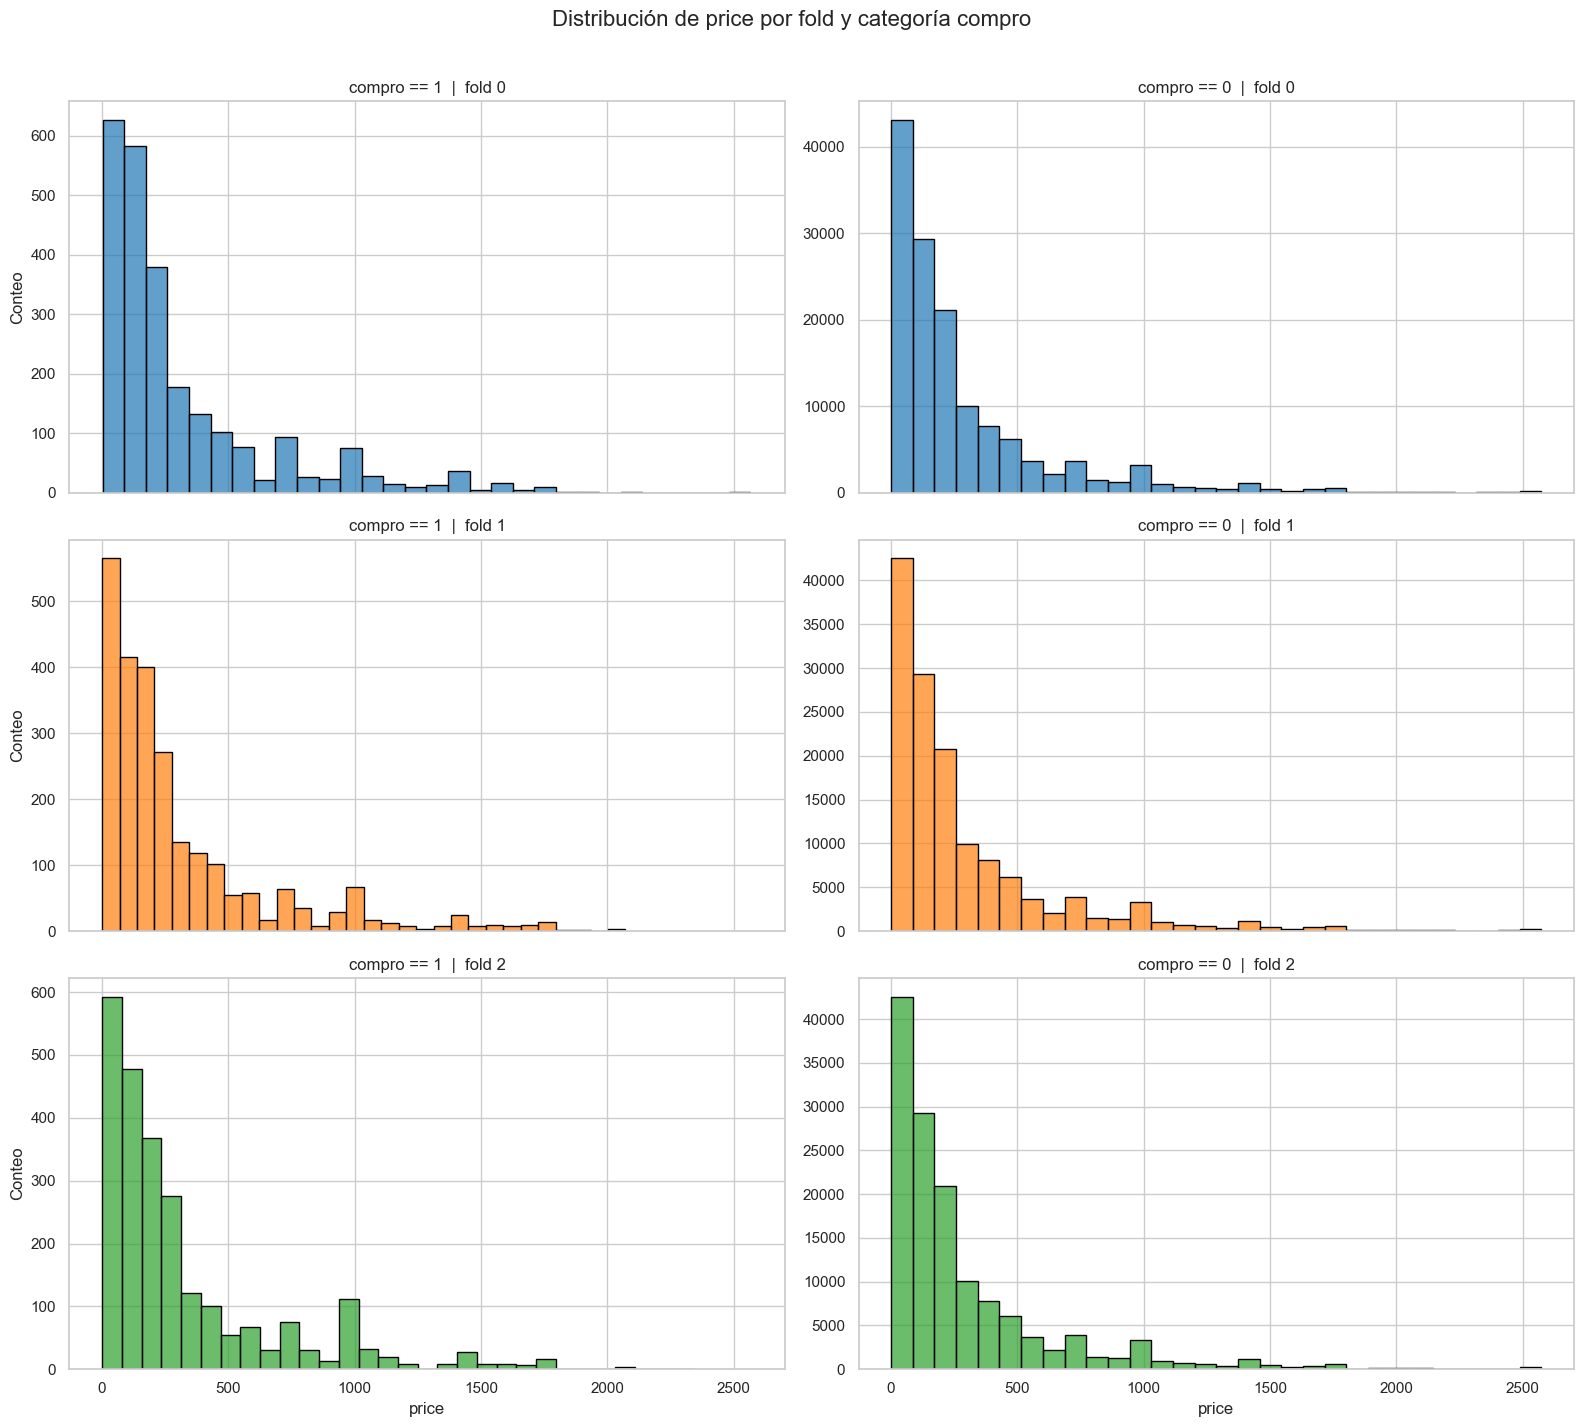

In [143]:
# ============================================================
# 12. VISUALIZACIÓN: HISTOGRAMAS DE PRICE POR FOLD
# ============================================================

# Histogramas de price por fold, separados por la categoría compro y en un diseño 3x2
pdf_hist = M_folds.select("compro", "price", "fold").toPandas()

fig, axes = plt.subplots(3, 2, figsize=(16, 15), sharex=True, sharey=False)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
folds = sorted(pdf_hist["fold"].unique())

for i, fold in enumerate(folds):
    ax_left = axes[i, 0]
    ax_right = axes[i, 1]

    sns.histplot(
        data=pdf_hist[(pdf_hist["compro"] == 1) & (pdf_hist["fold"] == fold)],
        x="price",
        color=colors[i],
        bins=30,
        alpha=0.7,
        edgecolor="black",
        ax=ax_left
    )
    ax_left.set_title(f"compro == 1  |  fold {fold}")
    ax_left.set_xlabel("price")
    ax_left.set_ylabel("Conteo")

    sns.histplot(
        data=pdf_hist[(pdf_hist["compro"] == 0) & (pdf_hist["fold"] == fold)],
        x="price",
        color=colors[i],
        bins=30,
        alpha=0.7,
        edgecolor="black",
        ax=ax_right
    )
    ax_right.set_title(f"compro == 0  |  fold {fold}")
    ax_right.set_xlabel("price")
    ax_right.set_ylabel("")

fig.suptitle("Distribución de price por fold y categoría compro", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

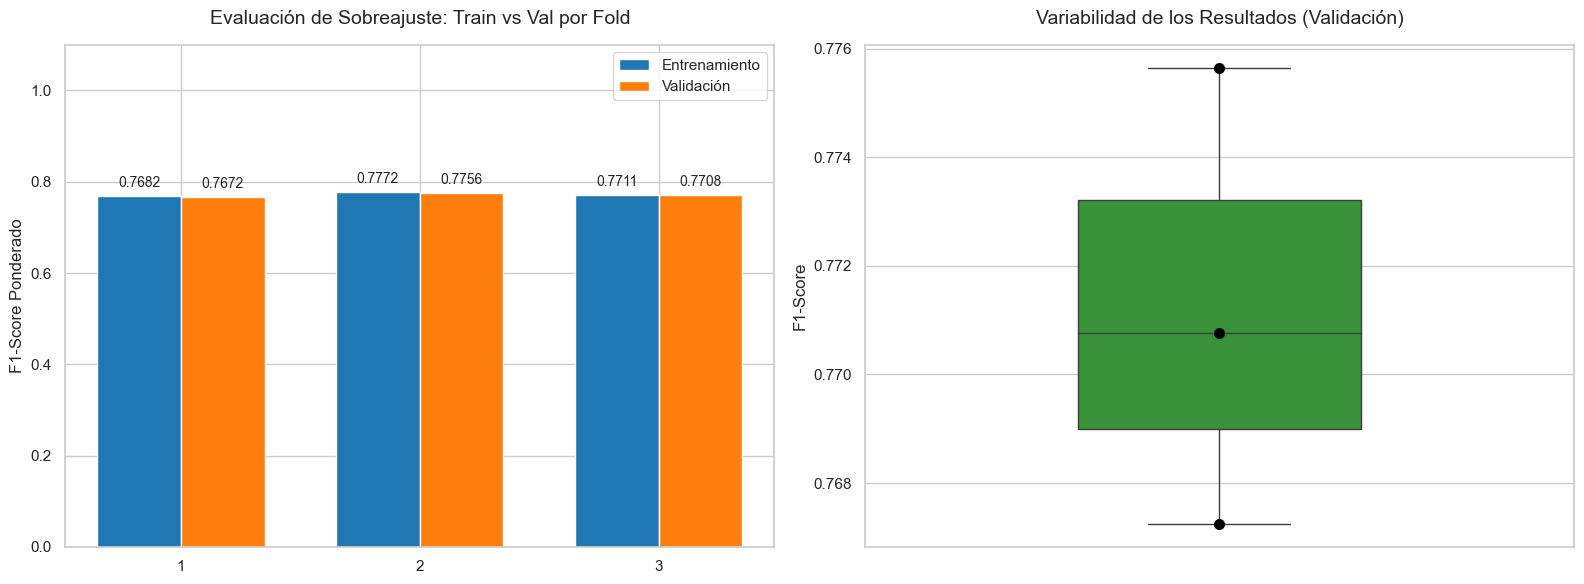


--- ESTADÍSTICAS GENERALES DE VALIDACIÓN CRUZADA ---
F1-Score Promedio (Validación): 0.7712
Desviación Estándar (Variabilidad): 0.0042


In [144]:
# ============================================================
# 13. VISUALIZACIÓN: TRAIN VS VALIDATION Y BOXPLOT
# ============================================================

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICA 1: Train vs Validation (Overfitting Check) ---
import numpy as np
x = np.arange(len(resultados_pdf['Fold']))
width = 0.35

axes[0].bar(x - width/2, resultados_pdf['F1_Train'], width, label='Entrenamiento', color='#1f77b4')
axes[0].bar(x + width/2, resultados_pdf['F1_Validation'], width, label='Validación', color='#ff7f0e')

axes[0].set_ylabel('F1-Score Ponderado')
axes[0].set_title('Evaluación de Sobreajuste: Train vs Val por Fold', fontsize=14, pad=15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(resultados_pdf['Fold'])
axes[0].legend()
axes[0].set_ylim(0, 1.1)

# Textos sobre las barras
for i, val in enumerate(resultados_pdf['F1_Train']):
    axes[0].text(i - width/2, val + 0.02, f'{val:.4f}', ha='center', fontsize=10)
for i, val in enumerate(resultados_pdf['F1_Validation']):
    axes[0].text(i + width/2, val + 0.02, f'{val:.4f}', ha='center', fontsize=10)

# --- GRÁFICA 2: Boxplot de Variabilidad ---
df_melted = resultados_pdf.melt(id_vars=['Fold'], value_vars=['F1_Validation'], var_name='Métrica', value_name='F1_Score')

sns.boxplot(y='F1_Score', data=df_melted, ax=axes[1], color='#2ca02c', width=0.4)
sns.swarmplot(y='F1_Score', data=df_melted, ax=axes[1], color='black', size=8)

axes[1].set_title('Variabilidad de los Resultados (Validación)', fontsize=14, pad=15)
axes[1].set_ylabel('F1-Score')

plt.tight_layout()
plt.show()

# Imprimir estadísticas descriptivas
print("\n--- ESTADÍSTICAS GENERALES DE VALIDACIÓN CRUZADA ---")
print(f"F1-Score Promedio (Validación): {resultados_pdf['F1_Validation'].mean():.4f}")
print(f"Desviación Estándar (Variabilidad): {resultados_pdf['F1_Validation'].std():.4f}")

## 13. Interpretación de resultados

La interpretación debe considerar tres elementos:

1. **Desempeño promedio:** el F1-score ponderado promedio resume el rendimiento general del modelo en los folds de validación.
2. **Estabilidad:** una baja desviación estándar entre folds sugiere que el modelo no depende excesivamente de una partición específica.
3. **Sobreajuste:** si el F1-score de entrenamiento es mucho mayor que el de validación, existe evidencia de sobreajuste. Si ambos valores son cercanos, el modelo generaliza de forma más estable.

Desde el punto de vista de negocio, el modelo busca identificar señales asociadas a la conversión de compra en eventos de eCommerce. Las variables de precio, categoría, marca agrupada y periodo temporal permiten representar patrones de navegación sin utilizar identificadores de alta cardinalidad como `user_id`, `product_id` o `user_session`.


In [145]:
# ============================================================
# 14. IMPORTANCIA DE VARIABLES DEL MEJOR MODELO
# ============================================================

# Seleccionar el modelo con mayor F1 de validación
best_idx = int(resultados_pdf["F1_Validation"].idxmax())
best_model = models[best_idx]

# Última etapa del pipeline: DecisionTreeClassificationModel
dt_model = best_model.stages[-1]
print(f"Mejor fold: {best_idx + 1}")
if hasattr(dt_model, 'depth'):
    print(f"Profundidad del árbol: {dt_model.depth}")
if hasattr(dt_model, 'numNodes'):
    print(f"Número de nodos: {dt_model.numNodes}")
print("\nImportancias de variables vectorizadas:")
if hasattr(dt_model, 'featureImportances'):
    print(dt_model.featureImportances)


Mejor fold: 2

Importancias de variables vectorizadas:
(78,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,15,16,17,19,20,21,22,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,49,50,51,54,55,56,57,58,60,61,62,64,65,66,67,68,69,70,71,72,73,74,76,77],[0.06869333568288095,0.024945497595814638,0.010004341026385961,0.008034509572172251,0.010787090385612546,0.009705190660727248,0.00474845374496947,0.004757953073739493,0.001297008358453112,0.01670629512692216,0.0007354155259384382,0.0013419159686084753,0.0014976477836064208,0.0011030214850067468,0.015673008179451678,0.0010555235961135507,0.003310683077007416,0.033218298989548825,0.022588261462701074,0.016190633031987447,0.026890563624469337,0.027344639609792033,0.027022092014203854,0.022844855658598603,0.021363795311663294,0.008741859162495496,0.009282077360469862,0.007999324978800123,0.004852917767864187,0.0005277981099221558,0.013521506085048901,0.010205828875384758,0.009688829703874495,0.02554459286889627,0.0006570783661714834,0.0060

## 13.1 Matriz de confusión, resultados por clase y curvas ROC / PR

Para responder a la recomendación de incluir métricas que no oculten el desempeño en la clase minoritaria, se reportan sobre el fold con mejor F1 de la clase compra: la **matriz de confusión**, **precisión / recall / F1 por clase**, el **AUC-ROC** y el **AUC-PR**, junto con las **curvas ROC y Precision-Recall**. En problemas desbalanceados la curva Precision-Recall y el recall de la clase positiva son más informativos que el accuracy o el F1 ponderado global.


Mejor fold por F1 de la clase compra: 2

--- Métricas por clase (validación) ---
Clase 0 (no compra): precision=0.9893  recall=0.6553  f1=0.7884
Clase 1 (compra): precision=0.0298  recall=0.5984  f1=0.0567

Matriz de confusión [filas=real, columnas=predicho]:
[[91196 47977]
 [  988  1472]]


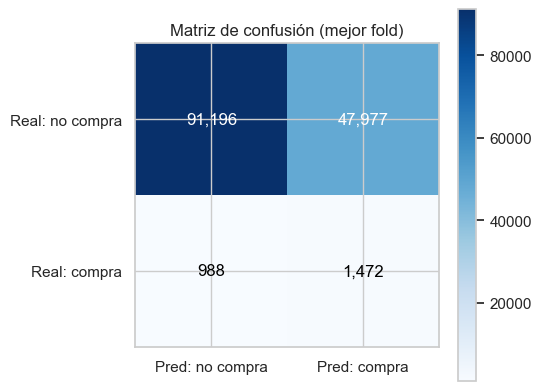


AUC-ROC: 0.6728 | AUC-PR: 0.0346


In [146]:
# ============================================================
# 15. MATRIZ DE CONFUSIÓN, MÉTRICAS POR CLASE Y CURVAS ROC / PR
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator_auc = BinaryClassificationEvaluator(
    labelCol="compro",
    rawPredictionCol="probability",
    metricName="areaUnderROC"
)

#auc_roc = evaluator_auc.evaluate(pred_best)
# Mejor modelo según el F1 de la clase minoritaria (compra)
best_idx = int(resultados_pdf["F1_compra"].idxmax())
best_model = models[best_idx]
print(f"Mejor fold por F1 de la clase compra: {best_idx + 1}")

val_best = M_folds.filter(F.col("fold") == best_idx)
pred_best = best_model.transform(val_best)
# --- Métricas por clase ---
print("\n--- Métricas por clase (validación) ---")
for lab, nombre in [(0.0, "no compra"), (1.0, "compra")]:
    p = per_label(pred_best, "precisionByLabel", lab)
    r = per_label(pred_best, "recallByLabel", lab)
    f = per_label(pred_best, "fMeasureByLabel", lab)
    print(f"Clase {int(lab)} ({nombre}): precision={p:.4f}  recall={r:.4f}  f1={f:.4f}")

# --- Matriz de confusión ---
cm_rows = pred_best.groupBy("compro", "prediction").count().collect()
cm = np.zeros((2, 2), dtype=int)
for row in cm_rows:
    cm[int(row["compro"])][int(row["prediction"])] = row["count"]
print("\nMatriz de confusión [filas=real, columnas=predicho]:")
print(cm)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm, cmap="Blues")
for (r, c), v in np.ndenumerate(cm):
    ax.text(c, r, f"{v:,}", ha="center", va="center",
            color="white" if v > cm.max() / 2 else "black", fontsize=12)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred: no compra", "Pred: compra"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Real: no compra", "Real: compra"])
ax.set_title("Matriz de confusión (mejor fold)")
plt.colorbar(im); plt.tight_layout(); plt.show()

# --- AUC-ROC, AUC-PR y curvas ---
auc_roc = evaluator_auc.evaluate(pred_best)
auc_pr = BinaryClassificationEvaluator(
    labelCol="compro", rawPredictionCol="probability",
    metricName="areaUnderPR").evaluate(pred_best)
print(f"\nAUC-ROC: {auc_roc:.4f} | AUC-PR: {auc_pr:.4f}")

score_label = pred_best.select("probability", "compro").rdd.map(
    lambda r: (float(r["probability"][1]), float(r["compro"])))




bcm = BinaryClassificationEvaluator(
    labelCol="compro", rawPredictionCol="probability",
    metricName="areaUnderROC"
)
roc = bcm.roc().collect()
pr = bcm.pr().collect()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot([p[0] for p in roc], [p[1] for p in roc], color="#1f77b4",
             label=f"ROC (AUC={auc_roc:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("Curva ROC"); axes[0].legend()

axes[1].plot([p[0] for p in pr], [p[1] for p in pr], color="#2ca02c",
             label=f"PR (AUC={auc_pr:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall"); axes[1].legend()
plt.tight_layout(); plt.show()

In [147]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

pdf = pred_best.select("probability", "compro").toPandas()

y_true = pdf["compro"].astype(int)
y_score = pdf["probability"].apply(lambda x: x[1])

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_true, y_score)
pr_auc = auc(recall, precision)

print("AUC-ROC:", roc_auc)
print("AUC-PR:", pr_auc)

AUC-ROC: 0.6727771305164497
AUC-PR: 0.03467345593486075


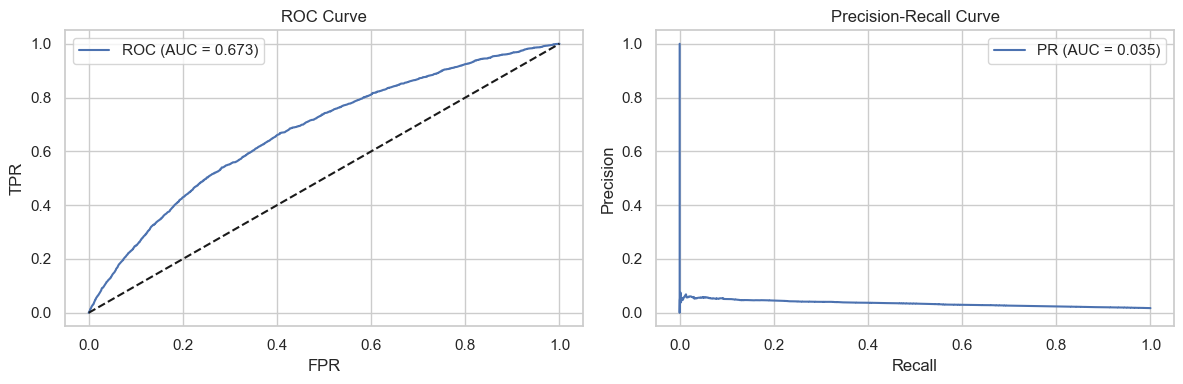

In [148]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f"PR (AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.tight_layout()
plt.show()

## 14. Conclusión técnica

**Qué se construyó.** El flujo procesa de forma reproducible ~42 millones de eventos de eCommerce con PySpark, desde la carga del CSV hasta la evaluación del modelo, conservando trazabilidad en cada etapa. La muestra se construye con muestreo estratificado proporcional sobre `event_type`, `category_group`, `price_range` y `time_period`, y se verifica (sección 8.1) que los folds son representativos por tamaño, por clase y por estrato.

**Qué significan los resultados.** Sin tratamiento del desbalance, el árbol colapsa a la clase mayoritaria: alcanza un F1 ponderado y un accuracy altos (~0.97–0.98) pero con recall de la clase compra igual a cero, es decir, no detecta ninguna conversión. Esto evidencia que, en este problema, el F1 ponderado y el accuracy son métricas engañosas. Por ello se incorporan pesos de clase balanceados (`weightCol`) y se reportan métricas por clase, matriz de confusión, AUC-ROC y AUC-PR (sección 15). El AUC-ROC mide la capacidad de ordenar correctamente compras frente a no compras independientemente del umbral, y la curva Precision-Recall describe el compromiso real entre detectar compras (recall) y la fracción de aciertos entre las predicciones positivas (precision).

**¿Generaliza el modelo?** La cercanía entre el F1 de entrenamiento y el de validación, junto con la baja desviación estándar entre folds (~1×10⁻⁴), indica que el modelo es estable y no sobreajusta: generaliza de forma consistente entre particiones. La limitación no es de generalización, sino de **capacidad discriminativa**: las variables disponibles describen el producto y el contexto, pero un mismo producto visto y comprado comparte esas características, por lo que a nivel de evento individual las clases son difíciles de separar sin información de sesión.

**Limitaciones del experimento.** (1) Se modelan eventos individuales y no secuencias de sesión, que aportarían la señal de intención de compra; (2) la clase compra es minoritaria (~1.74%), lo que exige rebalanceo; (3) el árbol individual es un modelo base limitado frente a alternativas de ensamble; (4) `brand` requiere agrupación por alta cardinalidad, lo que descarta marcas poco frecuentes.

**Trabajo futuro.** Construir variables a nivel de sesión (eventos previos, paso por carrito, tiempo en sesión), comparar contra Random Forest, Gradient-Boosted Trees y Logistic Regression con ajuste de hiperparámetros (CrossValidator + ParamGridBuilder), y desplegar el flujo en Databricks para ejecución productiva.
